# LeetCode #207: Course Schedule

https://leetcode.com/problems/course-schedule/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **DFS Cycle Detection** | $O(V + E)$ | $O(V + E)$ |
| **BFS (Kahn's Algorithm)** | $O(V + E)$ | $O(V + E)$ |

---

## Understanding the Methods

### DFS Cycle Detection
Build an adjacency list. Use three states per node: unvisited, visiting (in current DFS path), visited (fully explored). If we encounter a node in the "visiting" state, there is a cycle — return false.

### BFS (Kahn's Algorithm) ★
1. Build adjacency list and compute in-degree for each node.
2. Add all nodes with in-degree 0 to a queue.
3. Process the queue: for each node, decrement the in-degree of its neighbors. If a neighbor's in-degree reaches 0, add it to the queue.
4. Count processed nodes. If count equals `numCourses`, all courses can be finished (no cycle).

**Why this works:** Nodes with in-degree 0 have no unsatisfied prerequisites. Removing them reduces in-degrees of downstream nodes. If a cycle exists, nodes in the cycle never reach in-degree 0 and are never processed.

**Constraints:**
* `1 <= numCourses <= 2000`
* `0 <= prerequisites.length <= 5000`

## Solutions

### C#

In [ ]:
public class Solution {
    public bool CanFinish(int numCourses, int[][] prerequisites) {
        var adj = new List<int>[numCourses];
        int[] inDegree = new int[numCourses];
        
        for (int i = 0; i < numCourses; i++) adj[i] = new List<int>();
        
        foreach (var p in prerequisites) {
            adj[p[1]].Add(p[0]);
            inDegree[p[0]]++;
        }
        
        var queue = new Queue<int>();
        for (int i = 0; i < numCourses; i++) {
            if (inDegree[i] == 0) queue.Enqueue(i);
        }
        
        int count = 0;
        while (queue.Count > 0) {
            int node = queue.Dequeue();
            count++;
            foreach (int neighbor in adj[node]) {
                if (--inDegree[neighbor] == 0) queue.Enqueue(neighbor);
            }
        }
        
        return count == numCourses;
    }
}

### Python

In [ ]:
from collections import deque, defaultdict

class Solution:
    def canFinish(self, numCourses: int, prerequisites: list[list[int]]) -> bool:
        adj = defaultdict(list)
        in_degree = [0] * numCourses
        
        for course, prereq in prerequisites:
            adj[prereq].append(course)
            in_degree[course] += 1
        
        queue = deque(i for i in range(numCourses) if in_degree[i] == 0)
        count = 0
        
        while queue:
            node = queue.popleft()
            count += 1
            for neighbor in adj[node]:
                in_degree[neighbor] -= 1
                if in_degree[neighbor] == 0:
                    queue.append(neighbor)
        
        return count == numCourses

### Go

In [ ]:
func canFinish(numCourses int, prerequisites [][]int) bool {
    adj := make([][]int, numCourses)
    inDegree := make([]int, numCourses)
    
    for _, p := range prerequisites {
        adj[p[1]] = append(adj[p[1]], p[0])
        inDegree[p[0]]++
    }
    
    queue := []int{}
    for i := 0; i < numCourses; i++ {
        if inDegree[i] == 0 {
            queue = append(queue, i)
        }
    }
    
    count := 0
    for len(queue) > 0 {
        node := queue[0]
        queue = queue[1:]
        count++
        for _, neighbor := range adj[node] {
            inDegree[neighbor]--
            if inDegree[neighbor] == 0 {
                queue = append(queue, neighbor)
            }
        }
    }
    
    return count == numCourses
}

### Rust

In [ ]:
use std::collections::VecDeque;

impl Solution {
    pub fn can_finish(num_courses: i32, prerequisites: Vec<Vec<i32>>) -> bool {
        let n = num_courses as usize;
        let mut adj = vec![vec![]; n];
        let mut in_degree = vec![0i32; n];
        
        for p in &prerequisites {
            adj[p[1] as usize].push(p[0] as usize);
            in_degree[p[0] as usize] += 1;
        }
        
        let mut queue: VecDeque<usize> = (0..n)
            .filter(|&i| in_degree[i] == 0)
            .collect();
        
        let mut count = 0;
        while let Some(node) = queue.pop_front() {
            count += 1;
            for &neighbor in &adj[node] {
                in_degree[neighbor] -= 1;
                if in_degree[neighbor] == 0 {
                    queue.push_back(neighbor);
                }
            }
        }
        
        count == n
    }
}

## Example Scenarios

1. **Common Case — Linear Chain:** `numCourses = 4`, `prerequisites = [[1,0],[2,1],[3,2]]` → **true**. Chain: $0 \to 1 \to 2 \to 3$. Course 0 has in-degree 0 and enters the queue first. Processing cascades: each course reduces its successor's in-degree to 0. All 4 processed. WHY tricky: Linear dependencies force a unique topological order — the queue always has exactly 1 element.

2. **Slightly Complex — Diamond DAG:** `numCourses = 5`, `prerequisites = [[1,0],[2,0],[3,1],[3,2],[4,3]]` → **true**. Course 0 fans out to 1 and 2; both feed into 3, which feeds into 4. Course 3 has in-degree 2 — it enters the queue only after BOTH 1 and 2 are processed. WHY tricky: Tests the in-degree decrement for convergent edges — course 3's in-degree drops $2 \to 1 \to 0$.

3. **Edge Case — Time Factor (Maximum Graph):** `numCourses = 2000`, `prerequisites` = 5000 edges (max constraints) → depends on cycle presence. $O(V + E) = O(2000 + 5000) = O(7000)$ operations. WHY tricky: Even at max constraints, BFS topological sort is trivial. The real concern: DFS recursion depth up to 2000 could overflow in some languages — Kahn's BFS avoids recursion entirely.

4. **Edge Case — Space Factor (No Prerequisites):** `numCourses = 2000`, `prerequisites = []` → **true**. All courses independent. Every course has in-degree 0, so all 2000 enter the queue at initialization (maximum queue size). Adjacency list is empty. WHY tricky: Queue starts at maximum capacity (all $V$ nodes). Worst case for queue space but best case for time (no edges to process). $S = O(V + E) = O(V)$.

5. **Almost-Impossible — Cycle of All Nodes:** `numCourses = 2000`, `prerequisites` forming a cycle $0 \to 1 \to 2 \to \cdots \to 1999 \to 0$ → **false**. Every node has in-degree 1. Initial queue is empty. BFS processes 0 nodes. Since $0 \neq 2000$, cycle detected. WHY tricky: The largest possible cycle. Kahn's elegantly detects it: no node ever reaches in-degree 0, so the queue stays empty throughout.

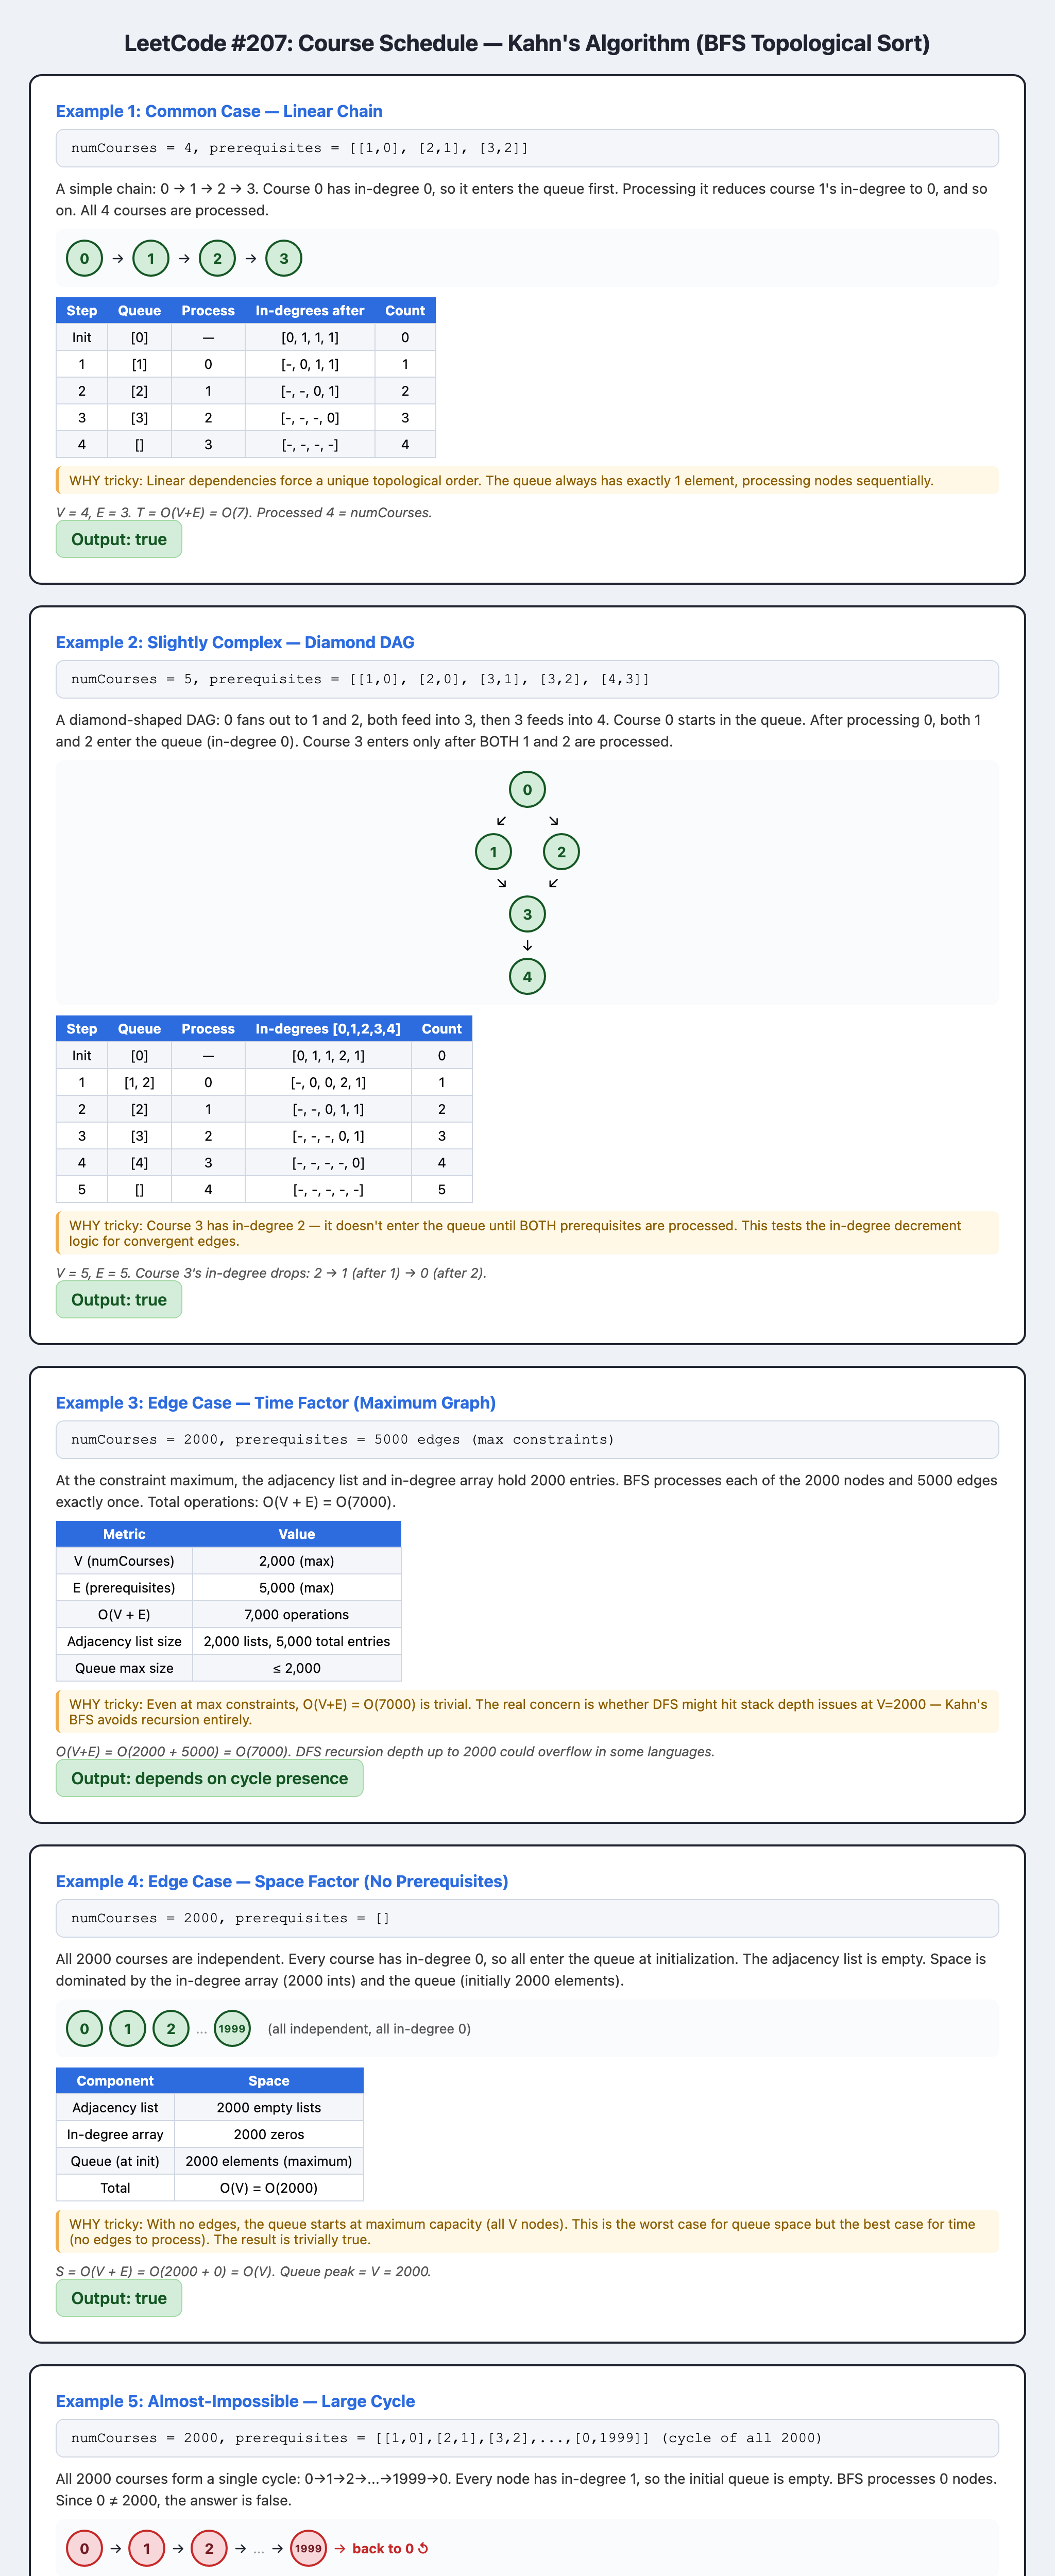